# Experiment 7.0 — Hierarchical context SNN

Analysis-only notebook. It consumes finalized method-level aggregate artifacts and intentionally does **not** display individual training runs, per-seed learning curves, or per-run rasters.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path('artifacts/experiment_7_0_hierarchical_context_snn/hierarchical_context_v1')
if not ROOT.exists():
    ROOT = Path('notebooks') / ROOT
summary = pd.read_csv(ROOT / 'summary.csv')
paired = pd.read_csv(ROOT / 'paired_neuron_deltas.csv')
method_deltas = pd.read_csv(ROOT / 'method_deltas.csv')
firing = pd.read_csv(ROOT / 'firing_summary.csv')


## Method-level test performance

In [2]:
display_cols = [
    'method', 'synapse_mode', 'n_runs',
    'val_ba_mean', 'val_ba_std',
    'test_ba_mean', 'test_ba_std',
    'test_accuracy_mean', 'test_macro_f1_mean',
]
summary[display_cols].sort_values('test_ba_mean', ascending=False).reset_index(drop=True)

,method,synapse_mode,n_runs,val_ba_mean,val_ba_std,test_ba_mean,test_ba_std,test_accuracy_mean,test_macro_f1_mean
0,local_snn_fixed250_linear,legacy_local,3,0.546914,0.030869,0.598780,0.013050,0.611872,0.600386
1,raw_fixed250_linear,reference,1,0.587290,NaN,0.548475,NaN,0.554795,0.537217
2,what_only,legacy,3,0.381756,0.045368,0.400226,0.032813,0.415525,0.378560
3,context_gain,legacy,3,0.342262,0.020643,0.363235,0.048522,0.372146,0.347141
4,all_skip,legacy,3,0.334546,0.028713,0.359876,0.020341,0.372146,0.344177
5,additive_context,legacy,3,0.357339,0.026743,0.340514,0.025436,0.349315,0.323565
6,additive_context,normalized,3,0.083333,0.000000,0.083333,0.000000,0.075342,0.011677
7,all_skip,normalized,3,0.083333,0.000000,0.083333,0.000000,0.075342,0.011677
8,context_gain,normalized,3,0.083333,0.000000,0.083333,0.000000,0.075342,0.011677
9,what_only,normalized,3,0.083333,0.000000,0.083333,0.000000,0.075342,0.011677


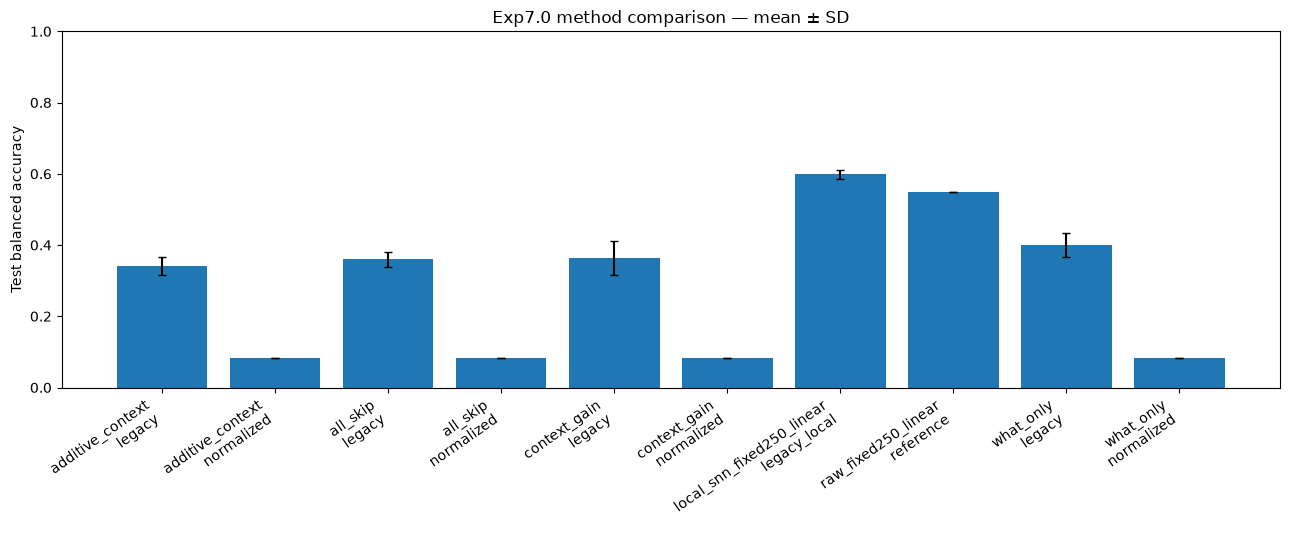

In [3]:
frame = summary.copy()
labels = frame['method'] + '\n' + frame['synapse_mode']
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.bar(range(len(frame)), frame['test_ba_mean'], yerr=frame['test_ba_std'].fillna(0), capsize=3)
ax.set_xticks(range(len(frame)))
ax.set_xticklabels(labels, rotation=35, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel('Test balanced accuracy')
ax.set_title('Exp7.0 method comparison — mean ± SD')
plt.tight_layout()
plt.show()

## Paired neuron-dynamics effect

Positive values mean normalized/unit-DC synaptic dynamics outperform the matched legacy run.

In [4]:
paired_summary = (
    paired.groupby('method')['normalized_minus_legacy_test_ba']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)
paired_summary

,method,mean,std,count
0,additive_context,-0.257180,0.025436,3
1,all_skip,-0.276542,0.020341,3
2,context_gain,-0.279902,0.048522,3
3,what_only,-0.316893,0.032813,3


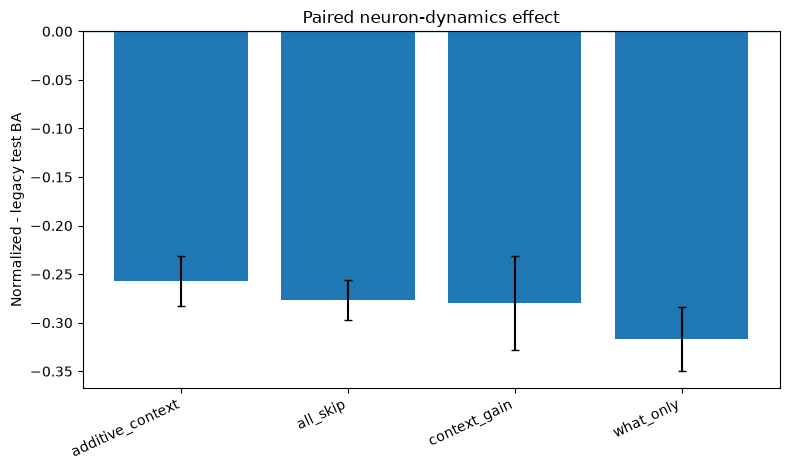

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(range(len(paired_summary)), paired_summary['mean'], yerr=paired_summary['std'].fillna(0), capsize=3)
ax.axhline(0, linewidth=1)
ax.set_xticks(range(len(paired_summary)))
ax.set_xticklabels(paired_summary['method'], rotation=25, ha='right')
ax.set_ylabel('Normalized - legacy test BA')
ax.set_title('Paired neuron-dynamics effect')
plt.tight_layout()
plt.show()

## Architecture contrasts

These contrasts directly test whether multiscale/additive/gated context improves over WHAT-only, and whether context gain improves over additive context.

In [6]:
contrast_summary = (
    method_deltas.groupby(['synapse_mode', 'contrast'])['test_ba_delta']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)
contrast_summary

,synapse_mode,contrast,mean,std,count
0,legacy,additive_context_minus_what,-0.059713,0.036835,3
1,legacy,all_skip_minus_what,-0.040351,0.051720,3
2,legacy,context_gain_minus_additive,0.022721,0.048378,3
3,legacy,context_gain_minus_what,-0.036991,0.015833,3
4,normalized,additive_context_minus_what,0.000000,0.000000,3
5,normalized,all_skip_minus_what,0.000000,0.000000,3
6,normalized,context_gain_minus_additive,0.000000,0.000000,3
7,normalized,context_gain_minus_what,0.000000,0.000000,3


## Aggregated firing and zero-tail persistence

This table is method-level aggregation only. It is intended to diagnose whether long legacy dynamics produce persistent firing after the valid endpoint.

In [7]:
firing.sort_values(['method', 'synapse_mode', 'layer']).reset_index(drop=True)

,method,synapse_mode,layer,n_runs,valid_firing_fraction_mean,valid_firing_fraction_std,zero_tail_firing_fraction_mean,zero_tail_firing_fraction_std,valid_spikes_per_neuron_second_mean
0,additive_context,legacy,long,3,0.117245,0.112055,0.221511,0.226756,7.503704
1,additive_context,legacy,middle,3,0.036748,0.053960,0.004926,0.006928,2.351852
2,additive_context,legacy,output,3,0.047840,0.042008,0.065930,0.057469,3.061728
3,additive_context,legacy,short,3,0.001505,0.001006,0.000016,0.000027,0.096296
4,additive_context,normalized,long,3,0.000000,0.000000,0.000000,0.000000,0.000000
5,additive_context,normalized,middle,3,0.000000,0.000000,0.000000,0.000000,0.000000
6,additive_context,normalized,output,3,0.000000,0.000000,0.000000,0.000000,0.000000
7,additive_context,normalized,short,3,0.000000,0.000000,0.000000,0.000000,0.000000
8,all_skip,legacy,long,3,0.094416,0.104431,0.270316,0.150710,6.042593
9,all_skip,legacy,middle,3,0.047164,0.075033,0.008503,0.010403,3.018519


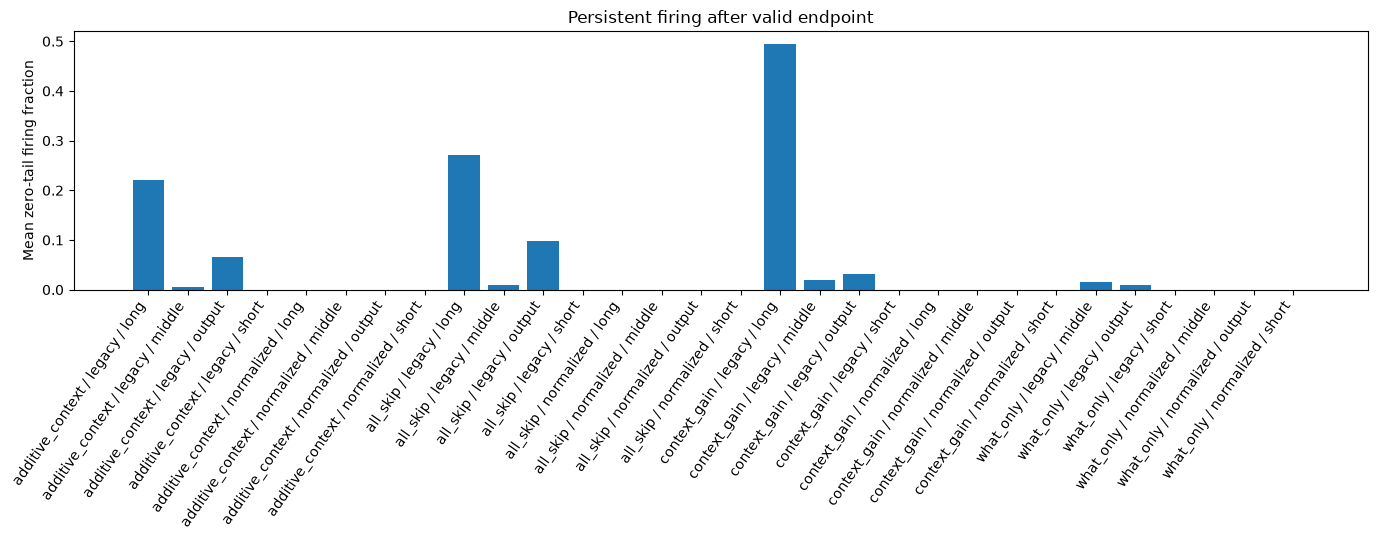

In [8]:
hier_firing = firing[firing['synapse_mode'].isin(['legacy', 'normalized'])].copy()
hier_firing['label'] = hier_firing['method'] + ' / ' + hier_firing['synapse_mode'] + ' / ' + hier_firing['layer']
fig, ax = plt.subplots(figsize=(14, 5.5))
ax.bar(range(len(hier_firing)), hier_firing['zero_tail_firing_fraction_mean'])
ax.set_xticks(range(len(hier_firing)))
ax.set_xticklabels(hier_firing['label'], rotation=55, ha='right')
ax.set_ylabel('Mean zero-tail firing fraction')
ax.set_title('Persistent firing after valid endpoint')
plt.tight_layout()
plt.show()